In [136]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
!pip install seaborn
!pip install torchvision torchaudio
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
!pip install scikit-learn
import sklearn
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [137]:
df = pd.read_excel('riskCalculation.xlsx')

In [138]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,ca,thal,target,cigs,RISK SCORE,"AGE >40, M or AGE > 55, F",HT,CHOL > 250,DM,CIGS
0,37,1,3,130,250,0,0,187,0,3.50,...,0.0,3.0,0,0,2,0,1,1.00,0,0
1,41,0,2,130,204,0,2,172,0,1.40,...,0.0,3.0,0,0,1,0,1,0.00,0,0
2,56,1,2,120,236,0,0,178,0,0.80,...,0.0,3.0,0,20,1,1,0,0.00,0,0
3,57,0,4,120,354,0,0,163,1,0.60,...,0.0,3.0,0,0,2,1,0,1.00,0,0
4,57,1,4,140,192,0,0,148,0,0.40,...,0.0,6.0,0,75,2,1,1,0.00,0,0


In [139]:
df.drop(['AGE >40,  M or AGE > 55, F ', 'HT', 'CHOL > 250', 'DM', 'CIGS', 'cigs', 'ca', 'thal', 'RISK SCORE'], axis=1, inplace=True)

In [140]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,37,1,3,130,250,0,0,187,0,3.50,3,0
1,41,0,2,130,204,0,2,172,0,1.40,1,0
2,56,1,2,120,236,0,0,178,0,0.80,1,0
3,57,0,4,120,354,0,0,163,1,0.60,1,0
4,57,1,4,140,192,0,0,148,0,0.40,2,0


In [141]:
df['target'] = df['target'].apply(lambda x: 1 if x >= 1 else 0)

In [142]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(), inplace=True)

In [143]:
def model_single_split(classifier, x_train, y_train, x_test, y_test):
    x_tr_scaled = x_train.copy()
    x_te_scaled = x_test.copy()

    mms_local = MinMaxScaler()
    ss_local = StandardScaler()

    x_tr_scaled[["oldpeak"]] = mms_local.fit_transform(x_tr_scaled[["oldpeak"]])
    x_te_scaled[["oldpeak"]] = mms_local.transform(x_te_scaled[["oldpeak"]])

    continuous_cols = ["age", "trestbps", "chol", "thalach"]
    x_tr_scaled[continuous_cols] = ss_local.fit_transform( x_tr_scaled[continuous_cols])
    x_te_scaled[continuous_cols] = ss_local.transform(x_te_scaled[continuous_cols])

    classifier.fit(x_tr_scaled, y_train)
    prediction = classifier.predict(x_te_scaled)

    prob_predictions = classifier.predict_proba(x_te_scaled)[:, 1]

    print("====== SINGLE TRAIN-TEST SPLIT RESULTS ======")
    print(
        "Test Set Accuracy :        ",
        "{0:.2%}".format(accuracy_score(y_test, prediction)),
    )
    print(
        "Test Set ROC_AUC Score :   ",
        "{0:.2%}".format(roc_auc_score(y_test, prob_predictions)),
    )

    RocCurveDisplay.from_estimator(classifier, x_te_scaled, y_test)
    plt.title("Single Split ROC_AUC_Plot")
    plt.show()

    return classifier, x_te_scaled


def evaluate_single_split(classifier, x_test_scaled, y_test):
    prediction = classifier.predict(x_test_scaled)

    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, prediction)
    names = ["True Neg", "False Pos", "False Neg", "True Pos"]
    counts = [value for value in cm.flatten()]
    percentages = [
        "{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)
    ]
    labels = [
        f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(names, counts, percentages)
    ]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, cmap="Blues", fmt="")
    plt.title("Single Split Confusion Matrix")
    plt.show()

    print("\n--- Localized Classification Report ---")
    print(classification_report(y_test, prediction))

In [144]:
features = df.drop(['target'], axis=1)
target = df['target']
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, random_state=2, stratify=target
)

====== SINGLE TRAIN-TEST SPLIT RESULTS ======
Test Set Accuracy :         77.19%
Test Set ROC_AUC Score :    84.50%


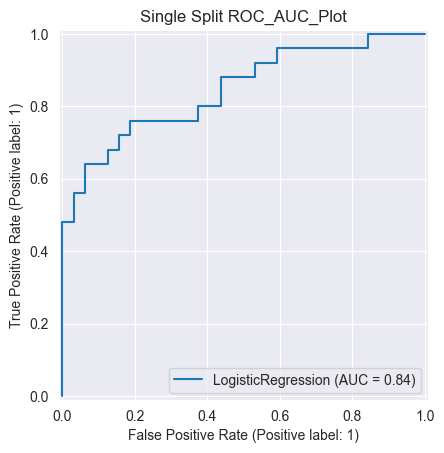

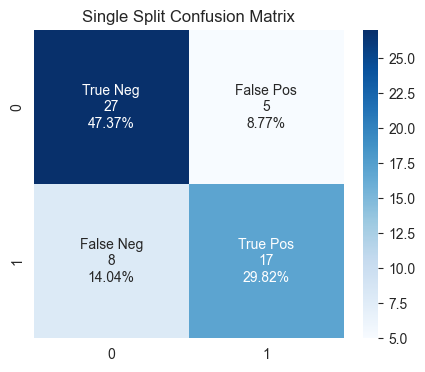


--- Localized Classification Report ---
              precision    recall  f1-score   support

           0       0.77      0.84      0.81        32
           1       0.77      0.68      0.72        25

    accuracy                           0.77        57
   macro avg       0.77      0.76      0.76        57
weighted avg       0.77      0.77      0.77        57



In [168]:
classifier_lr = LogisticRegression(random_state=2, C=10, penalty='l2', max_iter=1000)
fitted_model, x_test_scaled = model_single_split(classifier_lr, x_train, y_train, x_test, y_test)
evaluate_single_split(fitted_model, x_test_scaled, y_test)

In [146]:
def model(classifier, features, target):
    # Configure Cross-Validation
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2)

    # Empty lists to track scores across folds
    acc_scores = []
    auc_scores = []
    prec_scores = []
    rec_scores = []

    # Loop through each fold manually to scale without leakage
    for train_idx, test_idx in cv.split(features, target):
        # Isolate fold data frames
        X_tr, X_val = features.iloc[train_idx].copy(), features.iloc[test_idx].copy()
        y_tr, y_val = target.iloc[train_idx].values, target.iloc[test_idx].values

        mms_local = MinMaxScaler()
        ss_local = StandardScaler()

        # Scale features strictly based on the training fold parameters
        X_tr[["oldpeak"]] = mms_local.fit_transform(X_tr[["oldpeak"]])
        X_val[["oldpeak"]] = mms_local.transform(X_val[["oldpeak"]])

        continuous_cols = ["age", "trestbps", "chol", "thalach"]
        X_tr[continuous_cols] = ss_local.fit_transform(X_tr[continuous_cols])
        X_val[continuous_cols] = ss_local.transform(X_val[continuous_cols])

        # Train and predict on the scaled fold
        classifier.fit(X_tr, y_tr)
        preds = classifier.predict(X_val)
        probs = classifier.predict_proba(X_val)[:, 1]

        # Save metrics
        acc_scores.append(accuracy_score(y_val, preds))
        auc_scores.append(roc_auc_score(y_val, probs))
        prec_scores.append(precision_score(y_val, preds, zero_division=0))
        rec_scores.append(recall_score(y_val, preds, zero_division=0))

    # Print stable cross-validated metrics
    print("====== GLOBAL CROSS-VALIDATION RESULTS ======")
    print("Cross-Val Accuracy Score : ", "{0:.2%}".format(np.mean(acc_scores)))
    print("Cross-Val ROC_AUC Score :  ", "{0:.2%}".format(np.mean(auc_scores)))
    print("Cross-Val Precision Score: ", "{0:.2%}".format(np.mean(prec_scores)))
    print("Cross-Val Recall Score :    ", "{0:.2%}".format(np.mean(rec_scores)))

    # Scale the entire dataset for final plotting (standard practice for visualization)
    features_scaled = features.copy()
    mms_global = MinMaxScaler()
    ss_global = StandardScaler()

    features_scaled[["oldpeak"]] = mms_global.fit_transform(
        features_scaled[["oldpeak"]]
    )
    features_scaled[continuous_cols] = ss_global.fit_transform(
        features_scaled[continuous_cols]
    )

    classifier.fit(features_scaled, target)
    RocCurveDisplay.from_estimator(classifier, features_scaled, target)
    plt.title("Global ROC_AUC Plot (Scaled Data)")
    plt.show()

    return classifier

====== GLOBAL CROSS-VALIDATION RESULTS ======
Cross-Val Accuracy Score :  78.77%
Cross-Val ROC_AUC Score :   86.60%
Cross-Val Precision Score:  78.42%
Cross-Val Recall Score :     73.07%


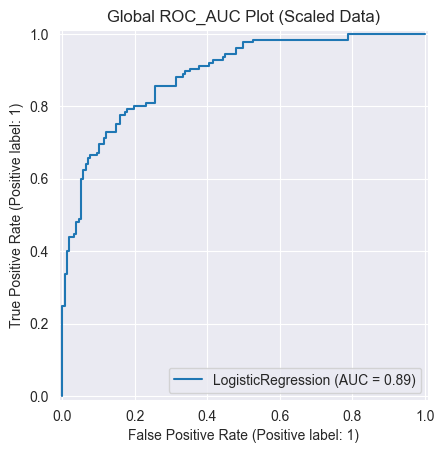

In [147]:
target = df['target']
features = df.drop(columns=['target'])

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, random_state=2)

fitted_pipeline = model(clf, features, target)

In [148]:
df_risk = pd.read_excel('riskCalculation.xlsx')

In [149]:
df_risk.drop(['AGE >40,  M or AGE > 55, F ', 'HT', 'CHOL > 250', 'DM', 'CIGS', 'cigs', 'ca', 'thal'], axis=1, inplace=True)

In [150]:
df_risk['target'] = df_risk['target'].apply(lambda x: 1 if x >= 1 else 0)

In [151]:
df_risk.replace('?', np.nan, inplace=True)
df_risk = df_risk.apply(pd.to_numeric, errors='coerce')
df_risk.fillna(df.median(), inplace=True)

In [152]:
features_risk = df_risk.drop(['target'], axis=1)
target_risk = df_risk['target']
x_train_risk, x_test_risk, y_train_risk, y_test_risk = train_test_split(features_risk, target_risk, test_size = 0.20, random_state = 2)

====== SINGLE TRAIN-TEST SPLIT RESULTS ======
Test Set Accuracy :         89.47%
Test Set ROC_AUC Score :    95.98%


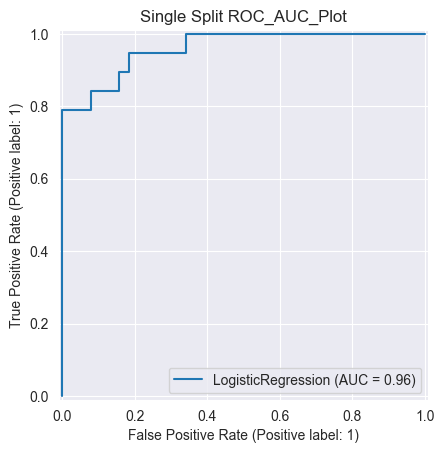

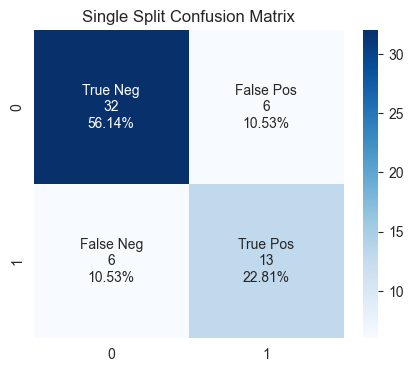


--- Localized Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        38
           1       0.68      0.68      0.68        19

    accuracy                           0.79        57
   macro avg       0.76      0.76      0.76        57
weighted avg       0.79      0.79      0.79        57



In [153]:
classifier_lr_risk = LogisticRegression(random_state=2, C=10, penalty='l2', max_iter=2000)

fitted_pipeline_risk, x_test_risk_scaled = model_single_split(classifier_lr_risk, x_train_risk, y_train_risk, x_test_risk, y_test_risk)

evaluate_single_split(fitted_pipeline_risk, x_test_risk, y_test_risk)

In [154]:

def model_riskscore(classifier, features, target):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2)
    acc_scores = []
    auc_scores = []
    prec_scores = []
    rec_scores = []

    for train_idx, test_idx in cv.split(features, target):
        X_tr, X_val = (
            features.iloc[train_idx].copy(),
            features.iloc[test_idx].copy(),
        )
        y_tr, y_val = target.iloc[train_idx].values, target.iloc[test_idx].values

        mms_local = MinMaxScaler()
        ss_local = StandardScaler()

        X_tr[["oldpeak"]] = mms_local.fit_transform(X_tr[["oldpeak"]])
        X_val[["oldpeak"]] = mms_local.transform(X_val[["oldpeak"]])

        X_tr[["RISK SCORE"]] = ss_local.fit_transform(X_tr[["RISK SCORE"]])
        X_val[["RISK SCORE"]] = ss_local.transform(X_val[["RISK SCORE"]])

        classifier.fit(X_tr, y_tr)
        preds = classifier.predict(X_val)
        probs = classifier.predict_proba(X_val)[:, 1]

        acc_scores.append(accuracy_score(y_val, preds))
        auc_scores.append(roc_auc_score(y_val, probs))
        prec_scores.append(precision_score(y_val, preds, zero_division=0))
        rec_scores.append(recall_score(y_val, preds, zero_division=0))

    print("====== GLOBAL CROSS-VALIDATION RESULTS ======")
    print("Cross-Val Accuracy Score : ", "{0:.2%}".format(np.mean(acc_scores)))
    print("Cross-Val ROC_AUC Score :  ", "{0:.2%}".format(np.mean(auc_scores)))
    print("Cross-Val Precision Score: ", "{0:.2%}".format(np.mean(prec_scores)))
    print("Cross-Val Recall Score :    ", "{0:.2%}".format(np.mean(rec_scores)))

    features_scaled = features.copy()
    mms_global = MinMaxScaler()
    ss_global = StandardScaler()

    features_scaled[["oldpeak"]] = mms_global.fit_transform(
        features_scaled[["oldpeak"]]
    )
    features_scaled[["RISK SCORE"]] = ss_global.fit_transform(
        features_scaled[["RISK SCORE"]]
    )

    classifier.fit(features_scaled, target)
    RocCurveDisplay.from_estimator(classifier, features_scaled, target)
    plt.title("Global ROC_AUC Plot (Only RISK SCORE & Oldpeak Scaled)")
    plt.show()

    return classifier

====== GLOBAL CROSS-VALIDATION RESULTS ======
Cross-Val Accuracy Score :  80.42%
Cross-Val ROC_AUC Score :   87.07%
Cross-Val Precision Score:  82.43%
Cross-Val Recall Score :     71.73%


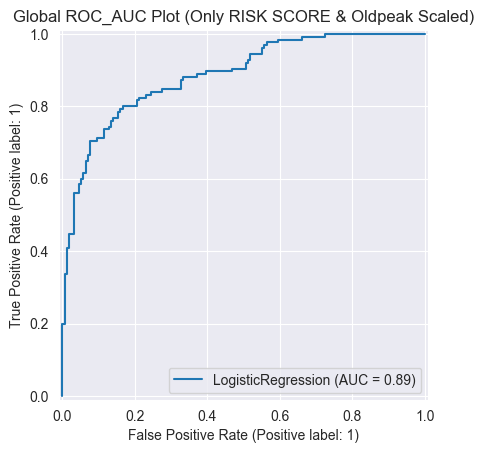

In [155]:
features_risk_removed = features_risk.drop( columns=["age", "trestbps", "chol", "cigs", "fbs"], errors="ignore")

fitted_pipeline = model_riskscore(clf, features_risk_removed, target_risk)

In [156]:
df_nn = df.copy()

In [157]:
df_nn

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,37,1,3,130,250,0,0,187,0,3.50,3,0
1,41,0,2,130,204,0,2,172,0,1.40,1,0
2,56,1,2,120,236,0,0,178,0,0.80,1,0
3,57,0,4,120,354,0,0,163,1,0.60,1,0
4,57,1,4,140,192,0,0,148,0,0.40,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
276,55,1,4,160,289,0,2,145,1,0.80,2,1
277,77,1,4,125,304,0,2,162,1,0.00,1,1
278,64,1,4,145,212,0,2,132,0,2.00,2,1
279,38,1,1,120,231,0,0,182,1,3.80,2,1


In [158]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    RocCurveDisplay
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(2)
np.random.seed(2)
torch.manual_seed(2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ShahMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 75),  # Hidden Layer: 75 Units
            nn.ReLU(),                 # Hidden Activation: ReLU
            nn.Linear(75, 1),          # Output Layer: 1 Unit
            nn.Sigmoid()               # Output Activation: Sigmoid
        )

    def forward(self, x):
        return self.network(x)


def model_paper_exact(features, target):
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2)

    accuracy_scores = []
    roc_scores = []
    precision_scores = []
    recall_scores = []

    last_x_test_raw = None
    last_y_test_raw = None
    last_net = None

    print("Executing Repeated Stratified K-Fold on df_nn...")

    for train_idx, test_idx in cv.split(features, target):
        X_train_df = features.iloc[train_idx].copy()
        X_test_df = features.iloc[test_idx].copy()
        y_train_raw = target.iloc[train_idx].values.reshape(-1, 1)
        y_test_raw = target.iloc[test_idx].values.reshape(-1, 1)

        mms_local = MinMaxScaler()
        ss_local = StandardScaler()

        X_train_df[["oldpeak"]] = mms_local.fit_transform(X_train_df[["oldpeak"]])
        X_test_df[["oldpeak"]] = mms_local.transform(X_test_df[["oldpeak"]])

        continuous_cols = ["age", "trestbps", "chol", "thalach"]
        X_train_df[continuous_cols] = ss_local.fit_transform(X_train_df[continuous_cols])
        X_test_df[continuous_cols] = ss_local.transform(X_test_df[continuous_cols])

        X_train = torch.tensor(X_train_df.values, dtype=torch.float32).to(device)
        X_test = torch.tensor(X_test_df.values, dtype=torch.float32).to(device)
        y_train = torch.tensor(y_train_raw, dtype=torch.float32).to(device)
        y_test = torch.tensor(y_test_raw, dtype=torch.float32).to(device)

        net = ShahMLP(features.shape[1]).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(net.parameters())

        epochs = 100
        for epoch in range(epochs):
            net.train()
            optimizer.zero_grad()
            outputs = net(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            optimizer.step()

        net.eval()
        with torch.no_grad():
            probabilities = net(X_test).cpu().numpy().flatten()

        predictions = (probabilities >= 0.5).astype(int)
        truth = y_test.cpu().numpy().flatten()

        accuracy_scores.append(accuracy_score(truth, predictions))
        roc_scores.append(roc_auc_score(truth, probabilities))
        precision_scores.append(precision_score(truth, predictions))
        recall_scores.append(recall_score(truth, predictions))

        last_x_test_raw = X_test_df
        last_y_test_raw = target.iloc[test_idx]
        last_net = net

    print("\n====== GLOBAL CROSS-VALIDATION RESULTS ======")
    print("Cross-Val Accuracy Score : ", "{:.2%}".format(np.mean(accuracy_scores)))
    print("Cross-Val ROC_AUC Score :  ", "{:.2%}".format(np.mean(roc_scores)))
    print("Cross-Val Precision Score: ", "{:.2%}".format(np.mean(precision_scores)))
    print("Cross-Val Recall Score :    ", "{:.2%}".format(np.mean(recall_scores)))
    print("==================================================")

    return last_net, last_x_test_raw, last_y_test_raw



In [115]:
x_train_nn = df_nn.drop(columns=['target'])
y_train_nn = df_nn['target']

fitted_net, x_eval, y_eval = model_paper_exact(x_train_nn, y_train_nn)

Executing Repeated Stratified K-Fold on df_nn...

====== GLOBAL CROSS-VALIDATION RESULTS ======
Cross-Val Accuracy Score :  74.02%
Cross-Val ROC_AUC Score :   82.59%
Cross-Val Precision Score:  72.77%
Cross-Val Recall Score :     67.73%


In [167]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

random.seed(2)
np.random.seed(2)
torch.manual_seed(2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_nn_df = df_nn.drop(columns=['target'])
y_nn = df_nn['target'].values
input_dim = X_nn_df.shape[1]

class DeepClassificationModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.40),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self._init_weights()

    def forward(self, x):
        return self.network(x)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                fan_in = m.weight.size(1)
                nn.init.normal_(m.weight, mean=0.0, std=np.sqrt(1.0 / fan_in))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

pytorch_accuracies, pytorch_aucs, pytorch_precisions, pytorch_recalls = [], [], [], []
skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_nn_df, y_nn), 1):
    X_tr_df = X_nn_df.iloc[train_idx].copy()
    X_val_df = X_nn_df.iloc[val_idx].copy()
    y_tr, y_val = y_nn[train_idx], y_nn[val_idx]

    mms_local = MinMaxScaler()
    ss_local = StandardScaler()

    X_tr_df[["oldpeak"]] = mms_local.fit_transform(X_tr_df[["oldpeak"]])
    X_val_df[["oldpeak"]] = mms_local.transform(X_val_df[["oldpeak"]])

    continuous_cols = ["age", "trestbps", "chol", "thalach"]
    X_tr_df[continuous_cols] = ss_local.fit_transform(X_tr_df[continuous_cols])
    X_val_df[continuous_cols] = ss_local.transform(X_val_df[continuous_cols])

    X_train_tensor = torch.tensor(X_tr_df.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)

    X_val_tensor = torch.tensor(X_val_df.values, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    model = DeepClassificationModel(input_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.NAdam(model.parameters(), lr=4e-4, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    patience = 25
    early_stop_counter = 0
    best_val_loss = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(500):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)

            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_tensor)
            val_loss = criterion(val_logits, y_val_tensor).item()

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            break

    model.load_state_dict(best_model_weights)
    model.eval()

    with torch.no_grad():
        final_logits = model(X_val_tensor)
        probs = torch.sigmoid(final_logits).cpu().numpy().squeeze()

    fpr, tpr, thresholds = roc_curve(y_val, probs)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    preds = (probs >= best_thresh).astype(int)

    acc = accuracy_score(y_val, preds)
    auc = roc_auc_score(y_val, probs)
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)

    pytorch_accuracies.append(acc)
    pytorch_aucs.append(auc)
    pytorch_precisions.append(prec)
    pytorch_recalls.append(rec)

    print(f"Fold {fold} → Accuracy: {acc*100:.2f}% | AUC: {auc*100:.2f}% | Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}%")

print("\n=========================================")
print("     PYTORCH NN — 5-FOLD STRATIFIED CV   ")
print("=========================================")
print(f"Mean CV Accuracy:  {np.mean(pytorch_accuracies):.4f}")
print(f"Mean CV ROC-AUC:   {np.mean(pytorch_aucs):.4f}")
print(f"Mean CV Precision: {np.mean(pytorch_precisions):.4f}")
print(f"Mean CV Recall:    {np.mean(pytorch_recalls):.4f}")
print("=========================================")




Fold 1 → Accuracy: 73.68% | AUC: 76.25% | Precision: 81.25% | Recall: 52.00%
Fold 2 → Accuracy: 80.36% | AUC: 84.39% | Precision: 81.82% | Recall: 72.00%
Fold 3 → Accuracy: 85.71% | AUC: 84.39% | Precision: 94.74% | Recall: 72.00%
Fold 4 → Accuracy: 76.79% | AUC: 81.42% | Precision: 83.33% | Recall: 60.00%
Fold 5 → Accuracy: 83.93% | AUC: 85.55% | Precision: 100.00% | Recall: 64.00%
Fold 6 → Accuracy: 80.70% | AUC: 80.75% | Precision: 85.00% | Recall: 68.00%
Fold 7 → Accuracy: 82.14% | AUC: 77.68% | Precision: 94.12% | Recall: 64.00%
Fold 8 → Accuracy: 83.93% | AUC: 89.94% | Precision: 78.57% | Recall: 88.00%
Fold 9 → Accuracy: 87.50% | AUC: 92.65% | Precision: 100.00% | Recall: 72.00%
Fold 10 → Accuracy: 69.64% | AUC: 73.29% | Precision: 61.76% | Recall: 84.00%
Fold 11 → Accuracy: 82.46% | AUC: 87.12% | Precision: 77.78% | Recall: 84.00%
Fold 12 → Accuracy: 82.14% | AUC: 90.19% | Precision: 75.86% | Recall: 88.00%
Fold 13 → Accuracy: 80.36% | AUC: 82.58% | Precision: 93.75% | Recall: 

In [127]:
df_nn['chol']

0      250
1      204
2      236
3      354
4      192
      ... 
276    289
277    304
278    212
279    231
280    166
Name: chol, Length: 281, dtype: int64

In [132]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")

df_stats = df_risk.copy()
y = df_stats['target']

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'RISK SCORE']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

results_list = []

def get_odds_ratio(feature_series, target_series):
    X_logit = sm.add_constant(feature_series)
    try:
        model = sm.Logit(target_series, X_logit).fit(disp=0)
        params = model.params
        conf = model.conf_int()

        odds_ratio = np.exp(params.iloc[1])
        ci_lower = np.exp(conf.iloc[1, 0])
        ci_upper = np.exp(conf.iloc[1, 1])

        return odds_ratio, ci_lower, ci_upper
    except Exception:
        return np.nan, np.nan, np.nan

for col in numerical_cols:
    if col not in df_stats.columns: continue
    feat = df_stats[col]
    g0, g1 = feat[y == 0], feat[y == 1]

    t_stat, t_pval = stats.ttest_ind(g0, g1, equal_var=False, nan_policy='omit')

    f_stat, _ = stats.f_oneway(g0, g1)

    r_pb, _ = stats.pointbiserialr(y, feat)

    v0, v1 = np.var(g0, ddof=1), np.var(g1, ddof=1)
    n0, n1 = len(g0), len(g1)
    pooled_std = np.sqrt(((n0 - 1) * v0 + (n1 - 1) * v1) / (n0 + n1 - 2))
    cohens_d = (np.mean(g1) - np.mean(g0)) / pooled_std if pooled_std > 0 else 0.0

    or_val, ci_low, ci_high = get_odds_ratio(feat, y)

    results_list.append({
        'Feature': col,
        'Type': 'Numerical',
        'ANOVA (F)': round(f_stat, 2),
        'T-Stat': round(t_stat, 3),
        'T-Test (p)': f"{t_pval:.4e}",
        "Cohen's d": round(cohens_d, 4),
        'Point-Biserial': round(r_pb, 4),
        'Odds Ratio': round(or_val, 3),
        '95% CI': f"[{ci_low:.2f}, {ci_high:.2f}]"
    })

for col in categorical_cols:
    if col not in df_stats.columns: continue
    feat = df_stats[col]

    or_val, ci_low, ci_high = get_odds_ratio(feat, y)

    results_list.append({
        'Feature': col,
        'Type': 'Categorical',
        'ANOVA (F)': '---',
        'T-Stat': '---',
        'T-Test (p)': '---',
        "Cohen's d": '---',
        'Point-Biserial': '---',
        'Odds Ratio': round(or_val, 3),
        '95% CI': f"[{ci_low:.2f}, {ci_high:.2f}]"
    })

df_final = pd.DataFrame(results_list)
print("\n=========================================================================================================")
print("                                 UNIVARIATE STATISTICAL FEATURE ANALYSIS                                 ")
print("=========================================================================================================")
print(df_final.to_string(index=False))
print("=========================================================================================================")


                                 UNIVARIATE STATISTICAL FEATURE ANALYSIS                                 
   Feature        Type ANOVA (F) T-Stat T-Test (p) Cohen's d Point-Biserial  Odds Ratio        95% CI
       age   Numerical     12.50  -3.60 3.7723e-04      0.42           0.21        1.05  [1.02, 1.08]
  trestbps   Numerical      5.73  -2.36 1.9124e-02      0.29           0.14        1.02  [1.00, 1.03]
      chol   Numerical      4.04  -2.03 4.3004e-02      0.24           0.12        1.00  [1.00, 1.01]
   thalach   Numerical     54.06   7.22 6.5806e-12     -0.88          -0.40        0.96  [0.95, 0.97]
   oldpeak   Numerical     60.97  -7.42 3.4674e-12      0.94           0.42        2.54  [1.91, 3.37]
RISK SCORE   Numerical     29.56  -5.43 1.2649e-07      0.65           0.31        1.84  [1.45, 2.34]
       sex Categorical       ---    ---        ---       ---            ---        4.38  [2.47, 7.78]
        cp Categorical       ---    ---        ---       ---            ---  

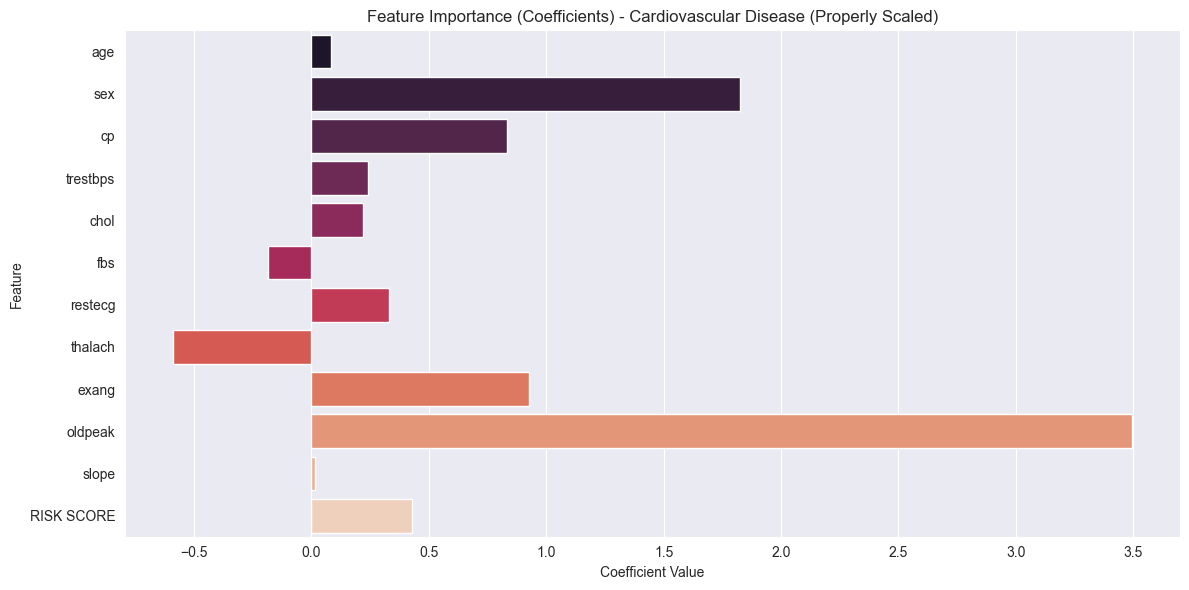

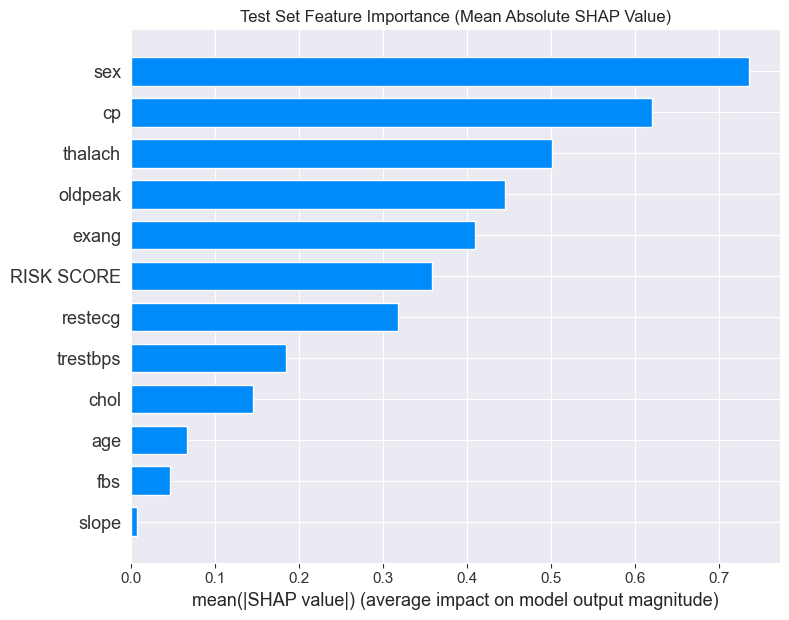


            CORRECTED TEST SET SHAP VALUES             
   Feature  Mean Absolute SHAP
       sex                0.74
        cp                0.62
   thalach                0.50
   oldpeak                0.45
     exang                0.41
RISK SCORE                0.36
   restecg                0.32
  trestbps                0.18
      chol                0.15
       age                0.07
       fbs                0.05
     slope                0.01


In [171]:

X = df_risk.drop(['target'], axis=1)
y = df_risk['target']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=2, stratify=y
)

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

mms_local = MinMaxScaler()
ss_local = StandardScaler()

x_train_scaled[["oldpeak"]] = mms_local.fit_transform(x_train_scaled[["oldpeak"]])
x_test_scaled[["oldpeak"]] = mms_local.transform(x_test_scaled[["oldpeak"]])

continuous_cols = ["age", "trestbps", "chol", "thalach"]
if "RISK SCORE" in x_train_scaled.columns:
    continuous_cols.append("RISK SCORE")

x_train_scaled[continuous_cols] = ss_local.fit_transform(x_train_scaled[continuous_cols])
x_test_scaled[continuous_cols] = ss_local.transform(x_test_scaled[continuous_cols])

classifier_lr = LogisticRegression(random_state=2, C=10, penalty='l2', max_iter=1000)
classifier_lr.fit(x_train_scaled, y_train)
importance = classifier_lr.coef_[0]
features = x_train_scaled.columns

plt.figure(figsize=(12, 6))
sns.barplot(x=importance, y=features, palette='rocket')
plt.title("Feature Importance (Coefficients) - Cardiovascular Disease (Properly Scaled)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


explainer = shap.LinearExplainer(classifier_lr, x_train_scaled)
shap_values = explainer.shap_values(x_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_scaled, feature_names=features, plot_type="bar", show=False)
plt.title("Test Set Feature Importance (Mean Absolute SHAP Value)")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': features,
    'Mean Absolute SHAP': mean_abs_shap
}).sort_values(by='Mean Absolute SHAP', ascending=False)

print("\n=======================================================")
print("            CORRECTED TEST SET SHAP VALUES             ")
print("=======================================================")
print(shap_df.to_string(index=False))
print("=======================================================")